## Topic 1: Introduction to Input Normalization in Neural Networks

### 1. Introduction

**What it is:**  
Input normalization (also called feature scaling) is the process of transforming all your input features so they exist on a **similar scale** (e.g., all between 0–1, or with mean 0 and standard deviation 1).

**Why it's important:**  
When features have very different ranges (e.g., Age: 0–100, Salary: 20,000–200,000), your neural network:
- Takes **much longer** to train
- May **never learn properly** (gets stuck)
- Updates weights **unsteadily**

**Real-life use:**  
Any dataset where features have different units or ranges — predicting purchases (age + salary), house prices (sq ft + number of rooms), medical diagnosis (age + blood pressure values).

---

### 2. Detailed Explanation
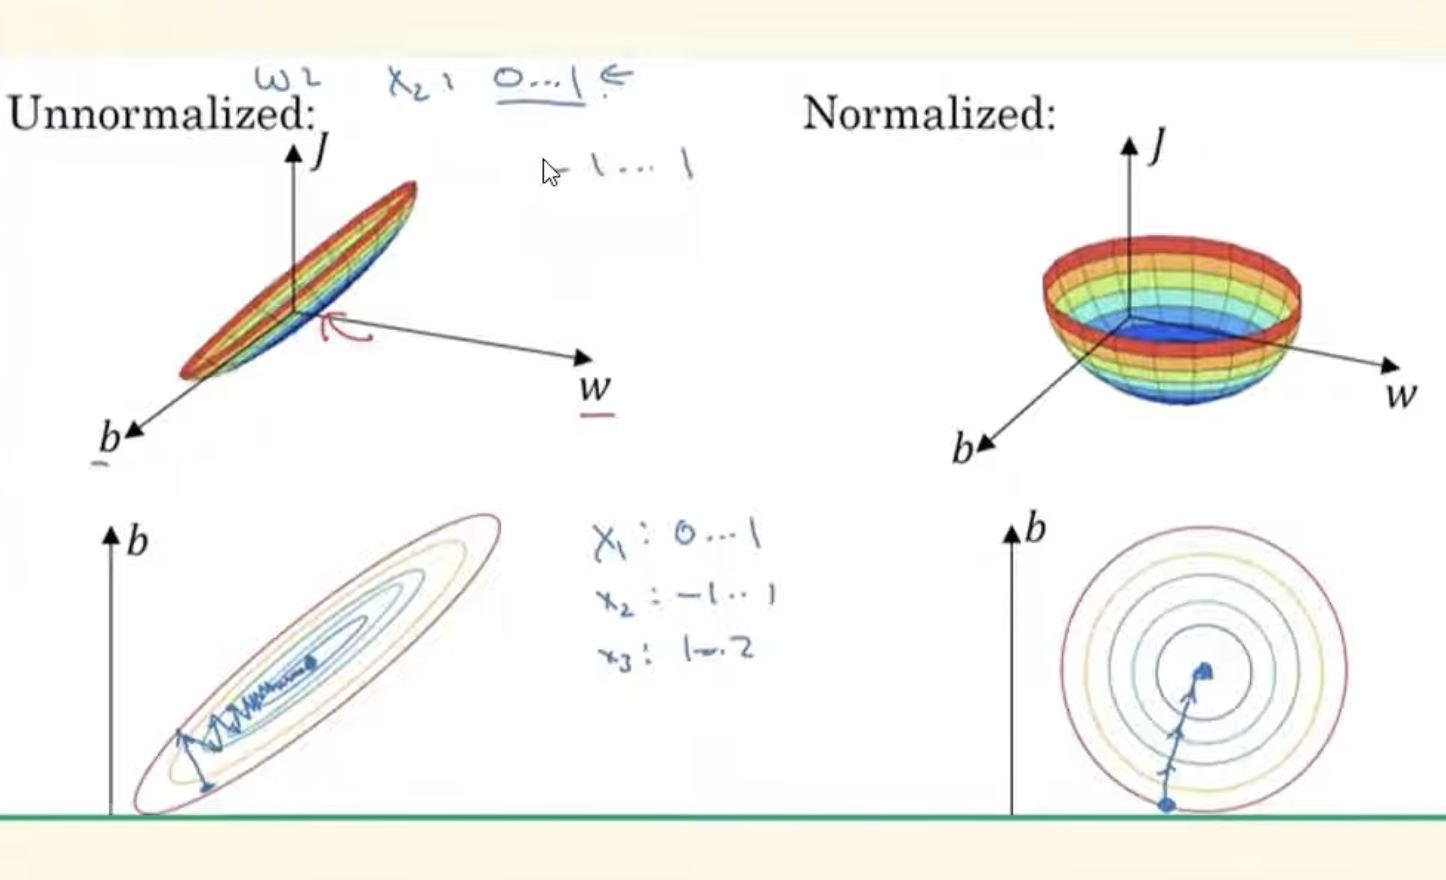
#### The Problem: Different Feature Ranges

Imagine you're building a neural network to predict whether someone buys a product. You have:
- **Age**: ranges from 0 to 100 (small range)
- **Salary**: ranges from 0 to 200,000+ (large range)

When you train a neural network with these raw values:

- The weight connected to **salary (w₂)** will see huge updates because salary values are large
- The weight connected to **age (w₁)** will see tiny updates by comparison
- Gradient descent focuses almost entirely on the large-range feature
- The network's **cost function graph becomes non-symmetric** (stretched/elongated) — like a narrow valley where gradient descent struggles to find the bottom

#### The Intuition (Geometric View)

| Without Normalization | With Normalization |
|----------------------|-------------------|
| Cost function is **non-symmetric**, elongated | Cost function is **symmetric**, spherical |
| Gradient descent zig-zags and takes many steps | Gradient descends smoothly toward optimum |
| Training is slow + unstable | Training is fast + stable |
| May never converge | Converges reliably |

> **Analogy:** Trying to find the lowest point in a long, narrow canyon vs. finding it in a round bowl. The bowl is much easier — you can go straight down.

#### The Solution: Two Main Scaling Methods

| Method | How It Works | When to Use |
|--------|--------------|-------------|
| **Standardization** | New value = (x - mean) / standard deviation → Results in mean=0, std=1 | When you don't know min/max values, or data has outliers |
| **Normalization (Min-Max)** | New value = (x - min) / (max - min) → Results in range [0, 1] | When you know the theoretical min/max (e.g., age 0–100, CGPA 0–10) |

**What both achieve:** All features are brought to a comparable scale. Gradient descent can now update all weights fairly.

---

### 3. Key Points

- **Different ranges** → slow/unstable training
- **Same ranges** → fast, stable convergence
- Standardization: `(x - mean) / std` → output ~ N(0,1)
- Min-Max Normalization: `(x - min) / (max - min)` → output in [0,1]
- Always scale **after** splitting train/test (fit on train only, then transform test)
- Scaling does NOT change the underlying pattern — only changes the magnitude

---

### 7. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|---------------|---------------|
| Scaling before train/test split | Data leakage — test info contaminates training | Split first, then fit scaler on train, transform both |
| Using different scalers for train and test | Inconsistent transformation | Use same scaler (fit on train) for both |
| Forgetting to scale at all | Slow/unstable training | Always scale inputs for neural networks |
| Applying scaling to categorical features | Not meaningful | Only scale numerical features |
| Scaling output/target variables | Usually unnecessary for classification | Scale only input features |

---

### 8. Interview/Exam Questions

**Q1: Why does a neural network take longer to train when input features have different scales?**  
*A:* Gradient descent focuses more on large-range features because small changes produce large weight updates. This makes the cost function non-symmetric and elongated, causing the optimizer to zig-zag rather than move directly toward the optimum.

**Q2: What is the difference between standardization and min-max normalization?**  
*A:* Standardization transforms data to have mean=0 and std=1 using `(x - μ)/σ`. Min-max normalization transforms data to a fixed range (usually [0,1]) using `(x - min)/(max - min)`.

**Q3: When would you choose normalization over standardization?**  
*A:* When you know the theoretical minimum and maximum values of your feature (e.g., age 0–100, CGPA 0–10). Otherwise, use standardization — especially if data has outliers or unknown bounds.

**Q4: Can scaling ever harm model performance?**  
*A:* Very rarely. In most cases, scaling helps or has no negative effect. It is considered a best practice for neural networks.

---

### 9. Revision Notes

- **Problem**: Different feature ranges → slow/unstable training
- **Cause**: Gradient descent overfocuses on large-range features
- **Cost function**: Becomes elongated/non-symmetric without scaling → hard to optimize
- **Solution**: Scale all features to similar range
- **Two methods**: Standardization (mean=0, std=1) OR Min-Max ([0,1])
- **Golden rule**: Always scale inputs before training a neural network
- **Result**: Faster convergence, better performance

---



## Topic 2: Demonstrating the Problem & Solution (With Code Walkthrough)

### 1. Introduction

The transcript provides a **practical demonstration** showing what happens when you train a neural network **without scaling** versus **with scaling**. The instructor uses a dataset with Age and Salary to predict purchase behavior (classification problem). This topic walks through that exact experiment so you can see the problem in action.

---

### 2. Detailed Explanation

#### Step 1: The Dataset

The dataset contains three features:
- **Age** – small range (approx. 0–100)
- **Salary** – large range (can be 20,000–200,000+)
- **Purchase** – target variable (buy or not buy – classification)

#### Step 2: Without Scaling (First Attempt)

**What the instructor did:**
1. Imported the dataset
2. Plotted Age vs Salary – showed very different distributions
3. Split data into train/test sets
4. Built a deep learning model:
   - Input layer (2 features: Age, Salary)
   - Hidden layer: **128 neurons** with ReLU activation
   - Output neuron: for binary classification (buy/not buy)
5. Compiled and trained the model

**What happened (the problem):**
| Metric | Result |
|--------|--------|
| Training accuracy | Stuck around **44–60%** |
| Validation accuracy | Could **never go above 60%** |
| Loss curve | Moving up and down (unstable) |
| Convergence | **Never reached** good solution |

> **The model failed to learn properly.**

#### Step 3: The Intuition Behind the Failure

With two features of vastly different scales:
- Weight for **Salary (w₂)** dominates gradient updates
- Weight for **Age (w₁)** gets ignored
- Gradient descent becomes **biased** toward the larger feature
- The cost function surface becomes **elongated** (non-symmetric)
- The optimizer struggles to find the minimum – like trying to walk down a narrow, steep canyon

#### Step 4: With Scaling (The Solution)

**What the instructor did:**
```python
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Fit on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME scaler
X_test_scaled = scaler.transform(X_test)
```

**What changed:**
- Age and Salary now on **same scale**
- Cost function became **symmetric** (spherical/round)
- Gradient descent could move **directly toward optimum**

**The result:**
| Metric | Without Scaling | With Scaling |
|--------|----------------|--------------|
| Training accuracy | ~44–60% | **~90%+** |
| Validation accuracy | Stuck <60% | **Improving alongside training** |
| Convergence | Never reached | **Reached true optimum** |

---

### 5. Code Examples (Extracted from Transcript)

#### Without Scaling (Problematic Code)

```python
# This code led to poor performance
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(2,)))  # 2 features: Age, Salary
model.add(Dense(1, activation='sigmoid'))  # Binary output

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training would get stuck ~44-60%
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)
```

#### With Scaling (Solution)

```python
from sklearn.preprocessing import StandardScaler

# Create and fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaler!

# Same model architecture – but now it works!
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(2,)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Now training reaches 90%+ accuracy
history = model.fit(X_train_scaled, y_train, 
                    validation_data=(X_val_scaled, y_val), 
                    epochs=100)
```

---

### 6. Output (What Changed)

| Phase | Accuracy (Without Scaling) | Accuracy (With Scaling) |
|-------|---------------------------|------------------------|
| Early epochs | ~44% | ~70% |
| Middle epochs | Fluctuating 44-60% | ~85% |
| Final epochs | Stuck <60% | **~90%+** |
| Validation | Never improves | **Improves with training** |

**Key observation:** After scaling, both training AND validation accuracy increased together – meaning the model was truly learning, not just memorizing.

---

### 7. Common Mistakes

| Mistake | Correct Approach |
|---------|------------------|
| Fitting scaler on entire dataset before splitting | Split first → fit on train only → transform train AND test using that fitted scaler |
| Using `.fit_transform()` on test data | Test data should only use `.transform()` – never `.fit()` again |
| Scaling categorical or binary features | Only scale numerical continuous features |
| Assuming scaling isn't necessary | For neural networks, **always scale inputs** as a default practice |

---

### 8. Interview/Exam Questions

**Q1: In the demonstration, why did the model get stuck at 44-60% accuracy without scaling?**  
*A:* Because Age (small range) and Salary (large range) had different scales. Gradient descent focused almost entirely on Salary, ignoring Age. The cost function became elongated and non-symmetric, making it impossible for the optimizer to find the true optimum.

**Q2: After applying StandardScaler, why did the same model architecture suddenly achieve 90%+ accuracy?**  
*A:* Scaling brought both features to the same scale (mean=0, std=1). This made the cost function symmetric and spherical, allowing gradient descent to move directly toward the optimum and update both weights fairly.

**Q3: The instructor used StandardScaler, not MinMaxScaler. Why was that appropriate here?**  
*A:* With Salary, we don't know the theoretical maximum (someone could earn any amount). Standardization handles unknown bounds and outliers better than min-max normalization.

**Q4: Should you scale the target variable (y) in a classification problem?**  
*A:* No. For classification, the target is categorical (0/1). For regression problems with large-range targets, scaling y can sometimes help, but typically only inputs are scaled.

---

### 9. Revision Notes

| Without Scaling | With Scaling |
|----------------|--------------|
| Training stuck at 44-60% | Training reaches 90%+ |
| Validation never improves | Validation improves with training |
| Loss unstable (up and down) | Loss decreases smoothly |
| Model fails to converge | Model converges reliably |
| Gradient descent biased | All weights updated fairly |

**The takeaway from the demonstration:**
> Scaling isn't optional for neural networks – it's a requirement for proper training. The same model architecture that failed completely started working perfectly after one line of preprocessing.

---


## Topic 3: Standardization vs. Normalization – Which One to Use & When

### 1. Introduction

The transcript explains **two different methods** to scale your features:
- **Standardization** (Z-score normalization)
- **Normalization** (Min-Max scaling)

Both bring features to a comparable scale, but they work differently and are suited for different situations. This topic breaks down exactly when to use each one.

---

### 2. Detailed Explanation

#### Method 1: Standardization (StandardScaler)

**Formula:**  
\[
x_{scaled} = \frac{x - \text{mean}}{\text{standard deviation}}
\]

**What it does:**
- Subtracts the mean → new mean = **0**
- Divides by standard deviation → new standard deviation = **1**
- Resulting distribution: approximately **standard normal** (not forced into a fixed range)

**Output range:** Typically between -3 and +3 (but can go beyond if there are outliers)

**When to use (per the transcript):**
- When you **don't know** the theoretical min/max of your feature
- When your data is **normally distributed** (bell curve)
- When you have **outliers** (standardization handles them better)
- Default choice when unsure

#### Method 2: Min-Max Normalization

**Formula:**  
\[
x_{scaled} = \frac{x - \text{min}}{\text{max} - \text{min}}
\]

**What it does:**
- Shifts data so minimum value becomes **0**
- Scales so maximum value becomes **1**
- All values are forced into **[0, 1]** range

**Output range:** Exactly between 0 and 1 (or any range you choose)

**When to use (per the transcript):**
- When you **know** the theoretical minimum and maximum values
- Examples given in transcript:
  - **Age** – min = 0, max = 100 (known bounds)
  - **CGPA** – min = 0, max = 10 (known bounds)
- When you need outputs in a bounded range (e.g., for image pixels 0-255 scaled to 0-1)

---

### Decision Flowchart (From Transcript)

```
Do you know the theoretical min and max of your feature?
                    |
        ┌───────────┴───────────┐
        │                       │
       YES                      NO
        │                       │
        ▼                       ▼
   Use Min-Max            Use Standardization
   Normalization          (StandardScaler)
   (range [0,1])
```

### Visual Comparison

| Aspect | Standardization | Min-Max Normalization |
|--------|----------------|----------------------|
| Formula | (x - μ) / σ | (x - min) / (max - min) |
| Output range | No fixed range (approx -3 to +3) | **Exactly [0, 1]** |
| Output mean | 0 | Depends on data |
| Output std dev | 1 | Depends on data |
| Sensitive to outliers? | Less sensitive | **Very sensitive** (outliers stretch the range) |
| Preserves shape of distribution | Yes | Yes |

---

### 3. Key Points

| If you know min/max (Age 0-100, CGPA 0-10) | → Use **Min-Max Normalization** |
| If you don't know bounds (Salary, house prices) | → Use **Standardization** |
| If data has outliers | → Use **Standardization** |
| If data is normally distributed | → Use **Standardization** |
| If you need exact range [0,1] (e.g., image pixels) | → Use **Min-Max Normalization** |
| Default choice for neural networks | → **Standardization** (most common) |

---

### 4. Syntax/Structure (How to Implement)

#### Standardization with Scikit-learn

```python
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit on training data (calculates mean and std)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same mean/std
X_test_scaled = scaler.transform(X_test)
```

#### Min-Max Normalization with Scikit-learn

```python
from sklearn.preprocessing import MinMaxScaler

# Create scaler (default range [0,1])
scaler = MinMaxScaler()

# Fit on training data (calculates min and max)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same min/max
X_test_scaled = scaler.transform(X_test)
```

---

### 8. Interview/Exam Questions

**Q1: You have a dataset with "Salary" (range 20,000–200,000, unknown upper bound) and "Age" (0–100). Which scaling method would you use and why?**  
*A:* Standardization for both, because Salary has no theoretical maximum. Using min-max on Salary would be sensitive to outliers (a CEO salary would stretch the whole scale).

**Q2: Your data is normally distributed with mean 50 and std 15. After standardization, what will the mean and std be?**  
*A:* Mean = 0, Standard deviation = 1. Standardization always centers data at zero and scales to unit variance.

**Q3: Why is min-max normalization more sensitive to outliers than standardization?**  
*A:* Min-max uses the actual min and max values. A single extreme outlier (e.g., Salary = $10 million) becomes the new max, compressing all other values into a tiny portion of [0,1]. Standardization uses mean and std, which are less affected by single outliers.

**Q4: After applying min-max normalization, can you ever get a value below 0 or above 1?**  
*A:* No, by definition all transformed values lie within the range you specify (default [0,1]), assuming no new values exceed the original min/max.

---

### 9. Revision Notes

| | Standardization | Min-Max Normalization |
|--|----------------|----------------------|
| **Formula** | (x - μ) / σ | (x - min) / (max - min) |
| **Output** | Mean=0, Std=1 | Fixed range [0,1] |
| **Known bounds?** | Not required | Required |
| **Outliers?** | Handles well | Problematic |
| **When to use** | Default choice, unknown bounds, outliers | Known min/max (Age, CGPA) |

**Golden Rule from Transcript:**
> "If you know the maximum and minimum value of your feature, do normalization. Otherwise, do standardization."

---



## Topic 4: Why Unscaled Features Break Gradient Descent (The Mathematical Intuition)

### 1. Introduction

The transcript provides a **geometric/mathematical intuition** for *why* unscaled features cause training problems. This topic explains that intuition clearly. You don't need advanced math to understand this — just the concept of a "cost function" and "gradient descent."

---

### 2. Detailed Explanation

#### What is a Cost Function?

Think of the cost function as a **map** or **landscape** where:
- **X-axis, Y-axis** = the weights of your neural network (w₁, w₂)
- **Z-axis (height)** = how wrong the network is (error/loss)
- **Goal** = find the lowest point on this map (minimum error)

When you train a neural network, gradient descent is like a hiker trying to reach the bottom of this valley.

#### What Happens with Unscaled Features?

When features have very different ranges (Age: 0–100 vs Salary: 20,000–200,000):

**The cost function becomes an elongated, narrow valley:**

```
Without Scaling (Non-symmetric cost function):
                    
                       \  
                        \  ← Very steep in one direction
                         \
                          \
                           \  ← Very shallow in the other
                            \
                             \
                              \
                               \________________
```

- One direction (Salary's weight) is **very steep** — large changes
- The other direction (Age's weight) is **very shallow** — tiny changes
- The valley is **elongated** (non-symmetric)

**The problem:** Gradient descent oscillates wildly in the steep direction while making almost no progress in the shallow direction.

#### What Happens with Scaled Features?

When features are on the same scale:

**The cost function becomes a symmetric, spherical bowl:**

```
With Scaling (Symmetric cost function):
                    
                       \    /
                        \  /
                         \/
                         /\
                        /  \
                       /    \
```

- All directions have **similar steepness**
- The shape is **round/spherical** (symmetric)
- Gradient descent can move **directly toward the center** (optimum)

**The result:** The optimizer finds the minimum quickly and reliably.

---

### The Key Insight (From Transcript)

| Without Scaling | With Scaling |
|----------------|--------------|
| Cost function is **elongated** | Cost function is **symmetric/spherical** |
| One weight dominates updates | All weights update fairly |
| Gradient descent zig-zags | Gradient descends straight |
| Slow or no convergence | Fast, reliable convergence |

> **Analogy from the transcript:** Trying to find the bottom of a long, narrow canyon vs. finding the bottom of a round bowl. The bowl is dramatically easier.

#### Why the Weight Update Gets Biased

Imagine two weights:
- **w₁** connects to Age (small values: 0–100)
- **w₂** connects to Salary (large values: 0–200,000+)

During backpropagation, the gradient for each weight depends on **the feature value**. Larger feature values → larger gradients → larger weight updates.

**Without scaling:**
- Gradient for w₂ (Salary) is **hundreds or thousands of times larger** than gradient for w₁ (Age)
- The algorithm "focuses" almost entirely on updating w₂
- w₁ barely changes, even if it's important

**With scaling:**
- Both features have similar magnitudes
- Gradients for w₁ and w₂ are balanced
- Both weights update fairly and appropriately

---

### 3. Key Points

- **Unscaled features** → cost function becomes **elongated/non-symmetric**
- **Scaled features** → cost function becomes **symmetric/spherical**
- Gradient descent struggles with elongated valleys (zig-zag, slow)
- Gradient descent excels with spherical bowls (direct path)
- Feature magnitudes directly affect gradient magnitudes
- The bias isn't in the data — it's in how gradient descent updates weights

---

### 8. Interview/Exam Questions

**Q1: Explain in simple terms why a neural network trains slowly when features have different scales.**  
*A:* The cost function landscape becomes a long, narrow valley instead of a nice round bowl. Gradient descent zig-zags back and forth across the steep direction, taking many small steps instead of moving straight toward the bottom.

**Q2: How does feature scale affect gradient magnitude during backpropagation?**  
*A:* The gradient for a weight is proportional to the feature value it multiplies. Larger feature values produce larger gradients, causing that weight to be updated much more aggressively than weights connected to smaller features.

**Q3: What does it mean that the cost function becomes "non-symmetric" without scaling?**  
*A:* It means the shape of the error landscape is stretched — very steep in some directions, very shallow in others. This makes optimization difficult because gradient descent can't move efficiently toward the minimum.

**Q4: After scaling, why does the cost function become symmetric/spherical?**  
*A:* When all features are on the same scale, the contribution of each weight to the error becomes balanced. The landscape becomes equally steep in all directions, forming a roughly spherical shape that gradient descent can navigate easily.

---

### 9. Revision Notes

**The Problem:**
- Different feature scales → different gradient magnitudes
- One weight dominates updates
- Cost function becomes elongated/non-symmetric
- Gradient descent zig-zags → slow convergence

**The Solution:**
- Scale features to same range
- Balanced gradient magnitudes
- Cost function becomes symmetric/spherical
- Gradient descends straight → fast convergence

**Remember:**
> Scaling doesn't change the data's pattern — it changes how easy it is for gradient descent to find that pattern.

---


## Topic 5: Best Practices, Summary & When to Always Scale

### 1. Introduction

This final topic consolidates everything from the transcript into **actionable best practices**. The instructor emphasizes that scaling should be your **default habit** whenever you train a neural network — not something you do only when you see problems.

---

### 2. Detailed Explanation

#### The Golden Rule (From the Transcript)

> **"Whenever I will give neural network data, I will scale it."**

This should be automatic, like checking that your data has no missing values. Even if scaling doesn't dramatically improve results, it almost never hurts.

#### Complete Step-by-Step Workflow

```
1. Split data into train / validation / test sets
                ↓
2. Fit scaler on TRAINING data only
     (calculates mean/std or min/max)
                ↓
3. Transform training data using that scaler
                ↓
4. Transform validation & test data using SAME scaler
     (no re-fitting!)
                ↓
5. Train neural network on scaled data
                ↓
6. Evaluate on scaled validation/test
```

#### Critical Rule: No Data Leakage

| ✅ Correct | ❌ Wrong |
|-----------|---------|
| Split first, then fit scaler on train | Fit scaler on entire dataset, then split |
| Transform test with train's scaler | Re-fit scaler on test data |
| Test data never influences scaling parameters | Test data influences mean/std/min/max |

**Why this matters:** If test data influences the scaler, your model has "seen" the test set indirectly — giving unrealistically good results that won't hold up in production.

---

### 3. Key Points Summary (From Entire Transcript)

| Concept | Key Takeaway |
|---------|--------------|
| **The problem** | Different feature ranges → slow/unstable training |
| **The cause** | Gradient descent overfocuses on large-range features |
| **The intuition** | Elongated cost function vs. spherical cost function |
| **Standardization** | `(x - μ)/σ` → output mean=0, std=1 → use when bounds unknown |
| **Min-Max Norm** | `(x - min)/(max - min)` → output [0,1] → use when bounds known |
| **Default choice** | Standardization (most common for neural nets) |
| **When to scale** | **Always** — make it a habit |
| **What not to scale** | Categorical/binary features |

---

### 4. The Complete Cheat Sheet (From Transcript)

The instructor mentions a "cheat sheet" of techniques to improve neural network performance:

| Technique | Status in This Video |
|-----------|---------------------|
| Early stopping | ✅ Covered in previous video |
| Input normalization | ✅ Covered in this video |
| Weight regularization | To be covered |
| Dropout | To be covered |
| Learning rate scheduling | To be covered |
| Hyperparameter tuning | To be covered |

**Your priority as a beginner:** Master input normalization first — it's the simplest and most immediately impactful technique.

---

### 8. Interview/Exam Questions

**Q1: As a best practice, when should you scale your input features for a neural network?**  
*A: Always. Make scaling a default step in your preprocessing pipeline, regardless of whether you think it's needed. It rarely hurts and often helps dramatically.

**Q2: You have a dataset with 10 numerical features and 3 categorical features. Which ones do you scale?**  
*A: Only the 10 numerical features. Categorical features (after encoding) should not be scaled — their values (0/1) are already on a consistent scale.

**Q3: If you forget to scale your inputs and your model trains fine, is it okay to skip scaling in the future?**  
*A: No. Just because it worked once doesn't mean it's optimal. Scaling is a best practice that improves convergence speed and stability. Make it a habit every time.

**Q4: Can scaling ever make performance worse?**  
*A: Very rarely. The transcript notes: "Sometimes there is no harm in scaling it either. It is beneficial in many scenarios." Scaling is considered safe and recommended.

---

### 9. Revision Notes (Complete Quick Recap)

```
┌─────────────────────────────────────────────────────────────┐
│           INPUT NORMALIZATION FOR NEURAL NETWORKS            │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  PROBLEM:  Different feature ranges → slow/unstable training│
│                                                             │
│  WHY:      Gradient descent focuses on large-range features │
│            Cost function becomes elongated (non-symmetric)  │
│                                                             │
│  SOLUTION: Scale features to similar range                  │
│                                                             │
│  METHODS:  • Standardization: (x - μ)/σ → mean=0, std=1    │
│            • Min-Max: (x - min)/(max - min) → [0,1]        │
│                                                             │
│  CHOOSE:   • Known min/max (Age, CGPA) → Min-Max           │
│            • Unknown bounds, outliers → Standardization    │
│                                                             │
│  PIPELINE: 1. Split train/test                             │
│            2. Fit scaler on TRAIN only                     │
│            3. Transform train, val, test with SAME scaler  │
│            4. Train on scaled data                         │
│                                                             │
│  GOLDEN RULE: Always scale inputs for neural networks!     │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

---

### Final Key Takeaway from the Transcript

> "You should always do this set. It has been noticed in experience that sometimes there is no harm in scaling it either. It is beneficial in many scenarios."

**As a beginner:** Make scaling your default habit. Before you train any neural network:
1. Check your numerical feature ranges
2. Choose StandardScaler (if unsure) or MinMaxScaler (if bounds known)
3. Scale after train/test split
4. Train on scaled data

This one step can take you from a model that gets stuck at 60% accuracy to one that reaches 90%+ — as demonstrated in the transcript.

---

**You've now completed all topics from the transcript.** 

